In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [81]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                             accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)

In [82]:
df = pd.read_csv("e-com_cleaned_dataset.csv")
df

,Order_ID,Customer_ID,Order_Date,Customer_Age,Customer_Segment,City,Region,Category,Product_Name,Sales_Channel,...,Website_Session_Minutes,Items_Viewed,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct
0,ORD100994,C1229,2025-06-07,44.0,Occasional,Delhi,Central,Sports,Shoes,Online,...,16.4,10,10,1.8,723.34,0.00,723.34,634.67,88.67,12.26
1,ORD101072,C1627,2025-03-18,51.0,Occasional,Kochi,West,Home Appliances,Shoes,Online,...,23.2,9,3,5.0,2639.48,328.29,2285.92,1613.24,612.14,28.36
2,ORD100995,C1410,2025-07-13,35.0,Occasional,Hyderabad,West,Electronics,Laptop,Online,...,9.1,10,6,3.0,739.05,105.68,633.37,370.35,263.02,41.53
3,ORD100731,C1578,2025-09-24,38.0,Regular,Bengaluru,North,Fashion,Shoes,Mobile App,...,22.7,4,4,3.6,28004.44,1473.03,26531.41,17911.62,8619.79,32.49
4,ORD102954,C1524,2025-06-09,39.0,Premium,Kolkata,South,Electronics,Skincare,Marketplace,...,6.6,8,8,2.5,9841.78,1842.38,7999.40,6214.63,1784.77,22.31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2847,ORD101148,C1685,2025-10-08,47.0,Premium,Delhi,East,Grocery,Novel,Mobile App,...,11.5,9,8,4.4,1111.95,313.24,798.71,646.78,151.93,19.02
2848,ORD102155,C1641,2025-09-15,27.0,Regular,Bengaluru,North,Home Appliances,Novel,Online,...,11.0,13,5,5.0,329.51,31.67,297.84,252.38,45.46,15.26
2849,ORD101767,C1457,2025-07-04,35.0,Premium,Bengaluru,East,Sports,Shirt,Store,...,9.5,6,4,3.1,20073.84,3894.32,16179.52,13306.36,2873.16,17.76
2850,ORD101123,C1789,2025-04-09,39.0,Occasional,Kochi,West,Sports,Shoes,Online,...,32.4,7,6,3.4,274.47,44.74,229.73,163.04,66.69,29.03


In [83]:
df.isnull().sum()

Order_ID                   0
Customer_ID                0
Order_Date                 0
Customer_Age               0
Customer_Segment           0
City                       0
Region                     0
Category                   0
Product_Name               0
Sales_Channel              0
Payment_Method             0
Device                     0
Quantity                   0
Unit_Price                 0
Discount_Pct               0
Shipping_Days              0
Customer_Rating            0
Delivery_Rating            0
Return_Status              0
Order_Status               0
Marketing_Source           0
Customer_Loyalty_Points    0
Website_Session_Minutes    0
Items_Viewed               0
Previous_Orders            0
Customer_Satisfaction      0
Gross_Amount               0
Discount_Amount            0
Net_Sales                  0
Estimated_Cost             0
Profit                     0
Profit_Margin_Pct          0
dtype: int64

In [84]:
df.duplicated().sum()

np.int64(0)

In [85]:
df.shape


(2852, 32)

In [86]:
df.dtypes

Order_ID                    object
Customer_ID                 object
Order_Date                  object
Customer_Age               float64
Customer_Segment            object
City                        object
Region                      object
Category                    object
Product_Name                object
Sales_Channel               object
Payment_Method              object
Device                      object
Quantity                     int64
Unit_Price                 float64
Discount_Pct               float64
Shipping_Days              float64
Customer_Rating            float64
Delivery_Rating            float64
Return_Status               object
Order_Status                object
Marketing_Source            object
Customer_Loyalty_Points    float64
Website_Session_Minutes    float64
Items_Viewed                 int64
Previous_Orders              int64
Customer_Satisfaction      float64
Gross_Amount               float64
Discount_Amount            float64
Net_Sales           

Order_Date is a date column. Instead of giving the raw date string to the model, we extract:

- `Order_Year`
- `Order_Month`
- `Order_Day`

In [87]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Order_Year"] = df["Order_Date"].dt.year
df["Order_Month"] = df["Order_Date"].dt.month
df["Order_Day"] = df["Order_Date"].dt.day

In [88]:
df = df.drop(columns=["Order_Year"])

In [89]:
df = df.drop(columns=["Order_ID", "Customer_ID"])

In [90]:
df.describe()

,Order_Date,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,...,Previous_Orders,Customer_Satisfaction,Gross_Amount,Discount_Amount,Net_Sales,Estimated_Cost,Profit,Profit_Margin_Pct,Order_Month,Order_Day
count,2852,2852.000000,2852.000000,2852.000000,2852.00000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,...,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000,2852.000000
mean,2025-07-02 02:53:11.023843072,35.404278,3.254909,1568.004386,15.16892,4.541024,3.747475,3.676017,869.173913,14.677139,...,5.004909,3.665288,5138.416476,753.366189,4285.255754,3064.366655,1213.317921,28.352048,6.532258,15.640252
min,2025-01-01 00:00:00,0.000000,1.000000,12.750000,0.00000,1.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,-1394.000000,12.040000,1.000000,1.000000
25%,2025-03-31 00:00:00,28.000000,2.000000,489.052500,8.54000,3.000000,3.300000,3.100000,377.000000,8.000000,...,3.000000,3.100000,1253.302500,119.872500,1097.265000,785.170000,293.767500,20.845000,3.000000,8.000000
50%,2025-07-01 00:00:00,35.000000,3.000000,922.380000,14.90500,4.000000,3.800000,3.700000,828.000000,12.700000,...,5.000000,3.700000,2639.480000,328.290000,2285.920000,1613.240000,612.140000,28.360000,7.000000,16.000000
75%,2025-10-02 00:00:00,42.000000,4.000000,1797.110000,21.08500,6.000000,4.300000,4.300000,1268.500000,19.300000,...,6.000000,4.300000,5578.300000,749.090000,4472.040000,3205.825000,1225.102500,35.602500,10.000000,23.000000
max,2025-12-31 00:00:00,102.000000,40.000000,61182.500000,75.00000,35.000000,5.000000,5.000000,2970.000000,96.100000,...,13.000000,5.000000,244730.000000,45519.780000,199210.220000,109806.220000,89404.000000,44.980000,12.000000,31.000000
std,NaN,11.137747,1.868876,2369.922175,9.29384,2.265459,0.734697,0.841038,618.464339,9.469406,...,2.289158,0.821690,9061.894474,1654.471979,7458.582159,5250.740997,2484.419099,9.018859,3.462787,8.820930


In [91]:
df.select_dtypes(include=np.number).corr()["Net_Sales"].sort_values(ascending=False)

Net_Sales                  1.000000
Estimated_Cost             0.983586
Gross_Amount               0.962388
Profit                     0.924182
Unit_Price                 0.820237
Discount_Amount            0.779221
Quantity                   0.322330
Items_Viewed               0.020611
Order_Month                0.014342
Delivery_Rating            0.013572
Order_Day                  0.009675
Profit_Margin_Pct          0.005947
Customer_Satisfaction      0.002945
Website_Session_Minutes    0.002773
Customer_Age              -0.001501
Customer_Loyalty_Points   -0.006623
Customer_Rating           -0.008825
Previous_Orders           -0.021622
Shipping_Days             -0.021988
Discount_Pct              -0.070684
Name: Net_Sales, dtype: float64

- A value close to `+1` indicates a strong positive relationship.
- A value close to `-1` indicates a strong negative relationship.
- A value close to `0` indicates a weak linear relationship.

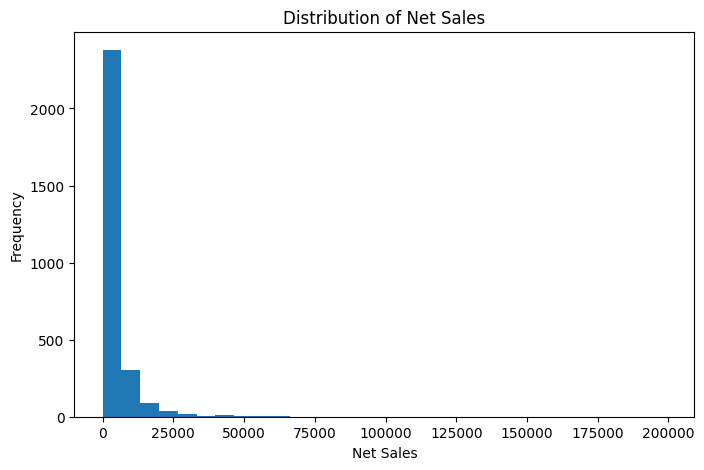

In [92]:
df["Net_Sales"].plot(kind="hist", bins=30, figsize=(8, 5))
plt.xlabel("Net Sales")
plt.ylabel("Frequency")
plt.title("Distribution of Net Sales")
plt.show()

The histogram shows the distribution of the target variable `Net_Sales`.

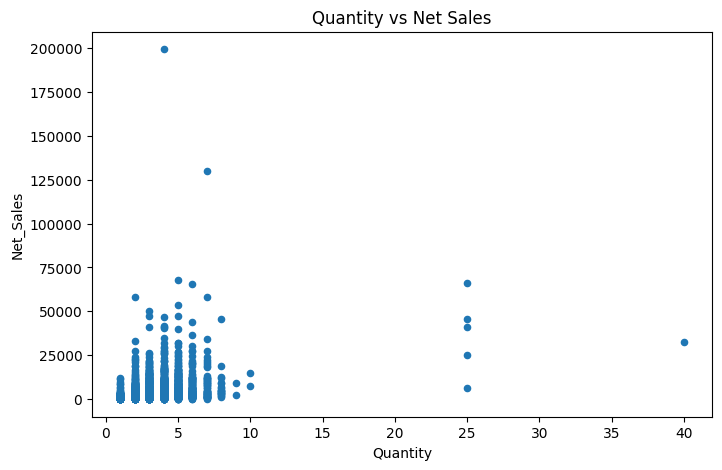

In [93]:
df.plot.scatter(x="Quantity", y="Net_Sales", figsize=(8, 5))
plt.title("Quantity vs Net Sales")
plt.show()

### Create X and Y DataFrames

In [94]:
feature_columns = [
    "Customer_Age",
    "Customer_Segment",
    "Region",
    "Category",
    "Sales_Channel",
    "Payment_Method",
    "Device",
    "Quantity",
    "Unit_Price",
    "Discount_Pct",
    "Shipping_Days",
    "Customer_Rating",
    "Delivery_Rating",
    "Marketing_Source",
    "Customer_Loyalty_Points",
    "Website_Session_Minutes",
    "Items_Viewed",
    "Previous_Orders",
    "Customer_Satisfaction",
    "Order_Month",
    "Order_Day"
]

X = df[feature_columns].copy()
Y = df[["Net_Sales"]].copy()

Y.head()

,Net_Sales
0,723.34
1,2285.92
2,633.37
3,26531.41
4,7999.40


In [95]:
categorical_columns = X.select_dtypes(include="object").columns
numerical_columns = X.select_dtypes(exclude="object").columns

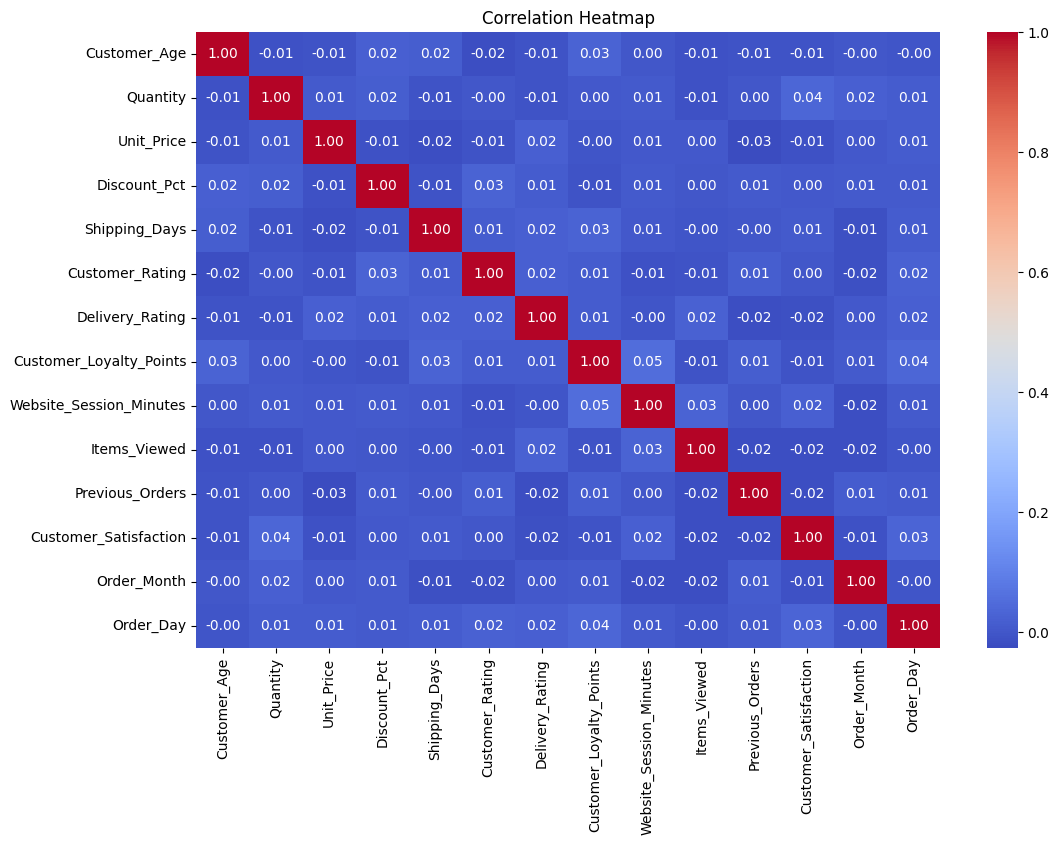

In [96]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

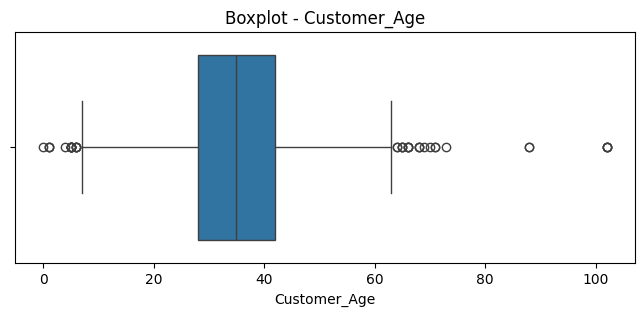

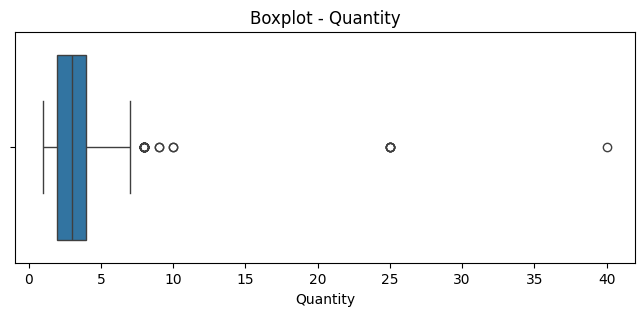

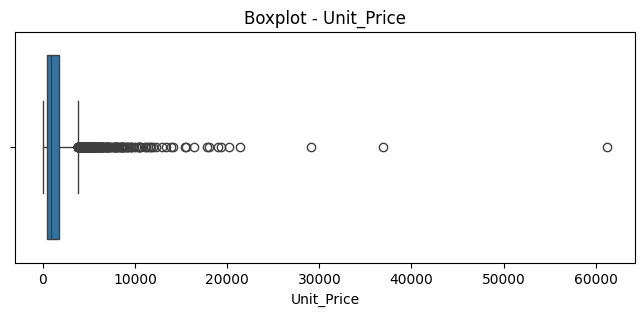

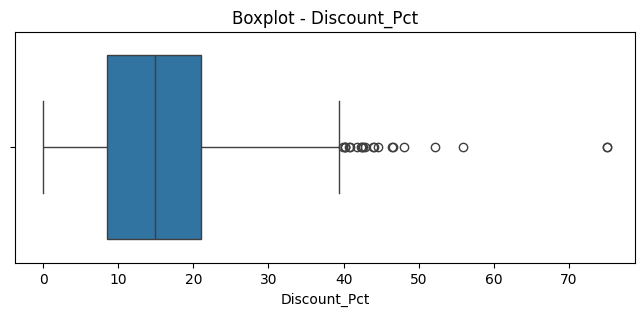

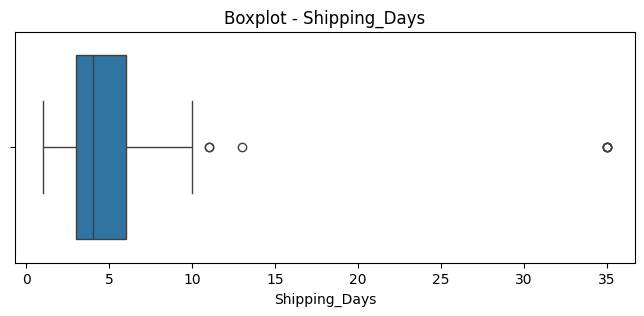

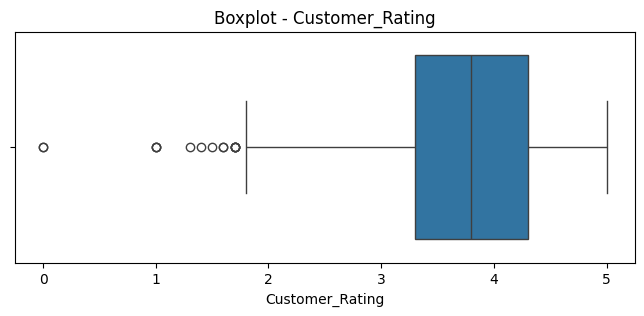

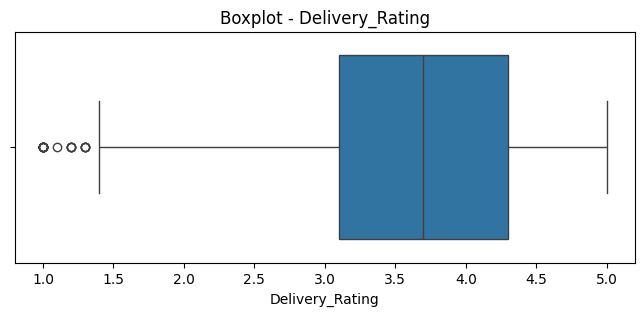

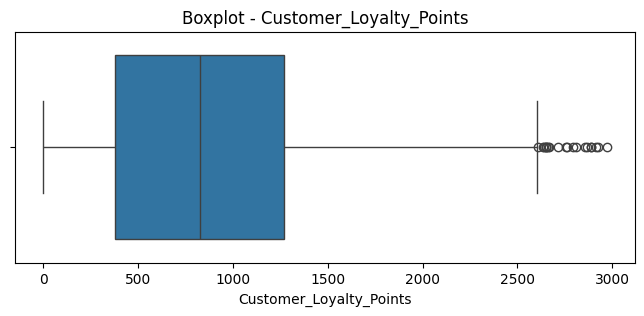

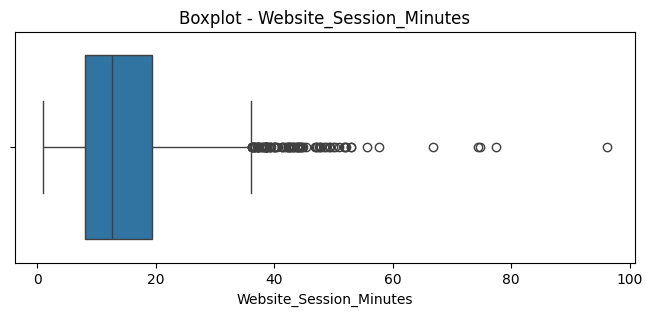

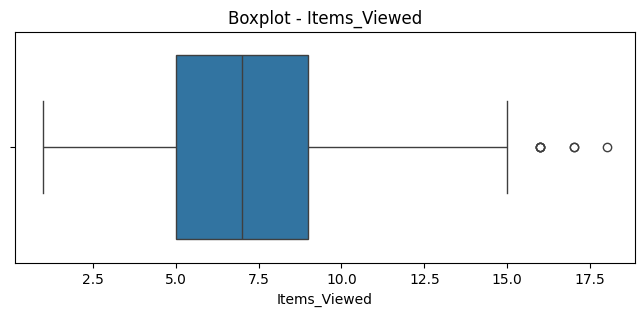

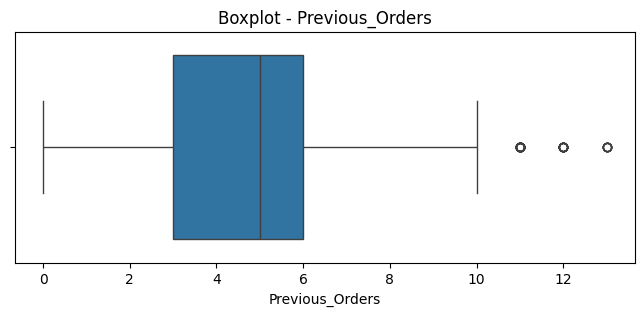

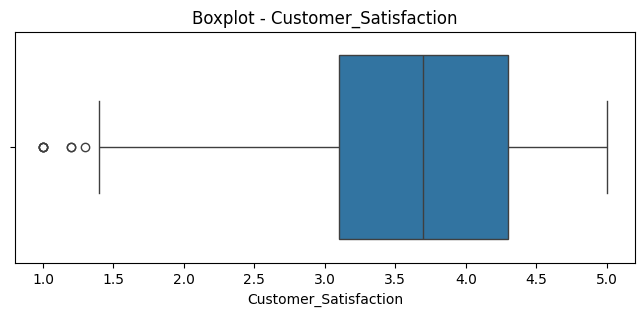

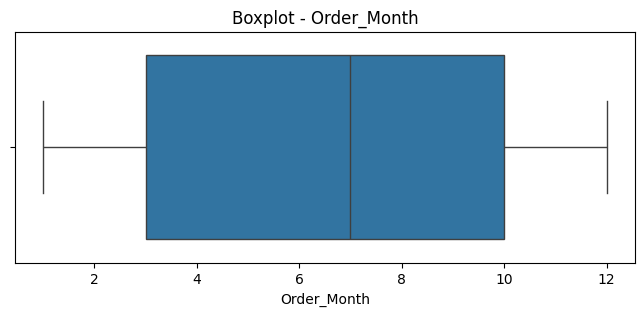

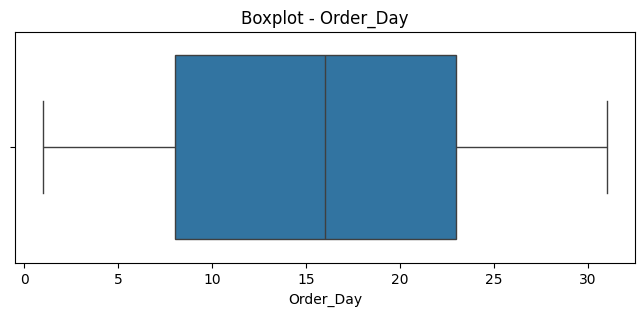

In [97]:
for col in numerical_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

### encoder

In [98]:
encoder = OneHotEncoder(
    drop="first",
    handle_unknown="ignore",
    sparse_output=False
)

X_categorical = encoder.fit_transform(X[categorical_columns])

X_categorical = pd.DataFrame(
    X_categorical,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X.index
)

X_numerical = X[numerical_columns]

X_encoded = pd.concat([X_numerical, X_categorical], axis=1)

X_encoded.head()

,Customer_Age,Quantity,Unit_Price,Discount_Pct,Shipping_Days,Customer_Rating,Delivery_Rating,Customer_Loyalty_Points,Website_Session_Minutes,Items_Viewed,...,Payment_Method_Net Banking,Payment_Method_Upi,Payment_Method_Wallet,Device_Laptop,Device_Mobile,Device_Tablet,Marketing_Source_Google Ads,Marketing_Source_Organic,Marketing_Source_Referral,Marketing_Source_Social Media
0,44.0,2,361.67,0.00,6.0,2.9,5.0,1062.0,16.4,10,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,51.0,2,922.38,28.01,5.0,2.5,3.6,1252.0,23.2,9,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,35.0,1,739.05,14.30,7.0,3.9,3.7,0.0,9.1,10,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,38.0,4,7001.11,5.26,4.0,3.5,3.5,1388.0,22.7,4,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,39.0,2,4920.89,18.72,4.0,5.0,4.6,1132.0,6.6,8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [99]:
X_encoded.shape

(2852, 43)

### Train-Test Split


In [100]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [101]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

In [102]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            RobustScaler(),
            numeric_features
        ),
    ]
)

In [103]:
X_train_scaled = preprocessor.fit_transform(X_train)

X_test_scaled = preprocessor.transform(X_test)

In [104]:

preprocessor.fit_transform(X_train)

preprocessor.transform(X_test)

array([[-0.78571429,  0.        , -0.65377331, ..., -0.5       ,
         1.        ,  0.08333333],
       [ 0.        , -1.        ,  1.21729807, ..., -0.75      ,
        -0.66666667, -1.        ],
       [ 0.21428571, -0.5       , -0.33927769, ...,  0.25      ,
         0.33333333, -1.41666667],
       ...,
       [-1.21428571,  0.5       , -0.20757831, ..., -1.25      ,
        -0.66666667,  0.41666667],
       [ 2.14285714,  1.5       , -0.52125598, ..., -0.5       ,
         0.66666667,  1.08333333],
       [ 0.07142857, -1.        ,  0.07842863, ..., -0.75      ,
        -1.33333333,  0.33333333]])

### LinearRegression

In [105]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(
    X_train_scaled,
    Y_train
)

LinearRegression()

In [106]:
Y_pred = model.predict(X_test_scaled)

In [107]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
print("\nModel Performance:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)


Model Performance:
MAE : 1561.4708005560035
MSE : 24064017.227220938
RMSE: 4905.508865267796
R²  : 0.8111043984931081


### KKN

In [108]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(
    n_neighbors=5,
    weights="distance",
    metric="euclidean"
)


knn_model.fit(
    X_train_scaled,
    Y_train.values.ravel()
)

print("KNN Regression model trained successfully!")

KNN Regression model trained successfully!


In [109]:
Y_pred_knn = knn_model.predict(X_test_scaled)

In [110]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae_knn = mean_absolute_error(Y_test, Y_pred_knn)
mse_knn = mean_squared_error(Y_test, Y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
r2_knn = r2_score(Y_test, Y_pred_knn)

print("\nKNN Regression Performance:")
print("MAE :", mae_knn)
print("MSE :", mse_knn)
print("RMSE:", rmse_knn)
print("R²  :", r2_knn)


KNN Regression Performance:
MAE : 1844.6421380860959
MSE : 70667264.87376371
RMSE: 8406.382389218546
R²  : 0.44528233257427574


### bagging 

In [111]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

bagging_model = BaggingRegressor(
    estimator=DecisionTreeRegressor(
        random_state=42
    ),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(
   X_train_scaled,
    Y_train
)

bagging_pred = bagging_model.predict(
    X_test_scaled
)

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_bagging.py:568: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True)


In [112]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

bagging_mae = mean_absolute_error(Y_test, bagging_pred)

bagging_mse = mean_squared_error(
    Y_test,
    bagging_pred
)

bagging_rmse = np.sqrt(bagging_mse)

bagging_r2 = r2_score(
    Y_test,
    bagging_pred
)

print("Bagging Regression")
print("------------------")
print("MAE :", bagging_mae)
print("MSE :", bagging_mse)
print("RMSE:", bagging_rmse)
print("R2  :", bagging_r2)

Bagging Regression
------------------
MAE : 972.9427232924694
MSE : 63191907.664871976
RMSE: 7949.333787486344
R2  : 0.5039617327392314


### boosting

In [113]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_model.fit(
    X_train_scaled,
    Y_train
)

gradient_pred = gradient_model.predict(
    X_test_scaled
)

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [114]:
gradient_mae = mean_absolute_error(
    Y_test,
    gradient_pred
)

gradient_mse = mean_squared_error(
    Y_test,
    gradient_pred
)

gradient_rmse = np.sqrt(gradient_mse)

gradient_r2 = r2_score(
    Y_test,
    gradient_pred
)

print("Gradient Boosting Regression")
print("----------------------------")
print("MAE :", gradient_mae)
print("MSE :", gradient_mse)
print("RMSE:", gradient_rmse)
print("R2  :", gradient_r2)

Gradient Boosting Regression
----------------------------
MAE : 1108.9784013544781
MSE : 68976301.09705521
RMSE: 8305.197234085124
R2  : 0.4585559109926953


### SVM

In [115]:

X_class = df.drop(columns=[
    "Return_Status",
    "Net_Sales",
    "Profit",
    "Profit_Margin_Pct"
])

Y_class = df["Return_Status"]

print("X shape:", X_class.shape)
print("Y shape:", Y_class.shape)

print("\nTarget values:")
print(Y_class.value_counts())

X shape: (2852, 28)
Y shape: (2852,)

Target values:
Return_Status
No     2473
Yes     379
Name: count, dtype: int64


drop order_date  

In [116]:
X_class = X_class.drop(columns=["Order_Date"])

In [117]:
from sklearn.model_selection import train_test_split

X_train_class, X_test_class, Y_train_class, Y_test_class = train_test_split(
    X_class,
    Y_class,
    test_size=0.2,
    random_state=42,
    stratify=Y_class
)

print("X_train:", X_train_class.shape)
print("X_test :", X_test_class.shape)

X_train: (2281, 27)
X_test : (571, 27)


In [118]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler

preprocessor_class = ColumnTransformer(
    transformers=[
        (
            "num",
            RobustScaler(),
            numeric_features_class
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features_class
        )
    ]
)

X_train_class_scaled = preprocessor_class.fit_transform(
    X_train_class
)

X_test_class_scaled = preprocessor_class.transform(
    X_test_class
)

print("Processed X_train:", X_train_class_scaled.shape)
print("Processed X_test :", X_test_class_scaled.shape)

Processed X_train: (2281, 66)
Processed X_test : (571, 66)


In [119]:
numeric_features_class = X_class.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_class = X_class.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:")
print(numeric_features_class)

print("\nCategorical:")
print(categorical_features_class)

Numerical:
['Customer_Age', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating', 'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed', 'Previous_Orders', 'Customer_Satisfaction', 'Gross_Amount', 'Discount_Amount', 'Estimated_Cost']

Categorical:
['Customer_Segment', 'City', 'Region', 'Category', 'Product_Name', 'Sales_Channel', 'Payment_Method', 'Device', 'Order_Status', 'Marketing_Source']


In [120]:
from sklearn.svm import SVC

svm_classifier = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    random_state=42
)

svm_classifier.fit(
    X_train_class_scaled,
    Y_train_class
)

SVC(random_state=42)

In [121]:
Y_pred_class = svm_classifier.predict(
    X_test_class_scaled
)

print(Y_pred_class[:20])

['No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No' 'No'
 'No' 'No' 'No' 'No' 'No' 'No']


In [122]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(
    Y_test_class,
    Y_pred_class
)

precision = precision_score(
    Y_test_class,
    Y_pred_class,
    average="weighted"
)

recall = recall_score(
    Y_test_class,
    Y_pred_class,
    average="weighted"
)

f1 = f1_score(
    Y_test_class,
    Y_pred_class,
    average="weighted"
)

print("SVM Classification")
print("------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

SVM Classification
------------------
Accuracy : 0.8669001751313485
Precision: 0.7515159136427628
Recall   : 0.8669001751313485
F1 Score : 0.8050949093621341


c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [123]:
print(
    classification_report(
        Y_test_class,
        Y_pred_class
    )
)

              precision    recall  f1-score   support

          No       0.87      1.00      0.93       495
         Yes       0.00      0.00      0.00        76

    accuracy                           0.87       571
   macro avg       0.43      0.50      0.46       571
weighted avg       0.75      0.87      0.81       571



c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

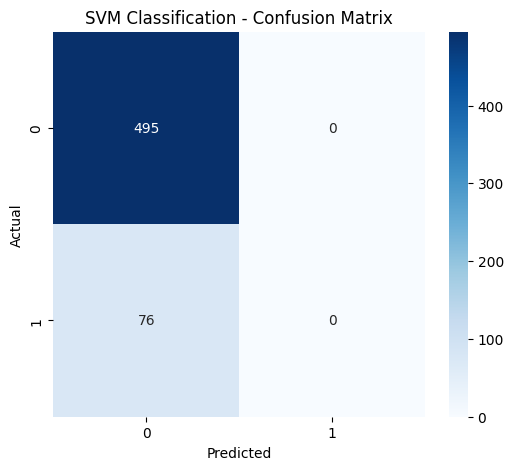

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    Y_test_class,
    Y_pred_class
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Classification - Confusion Matrix")

plt.show()

### SVM Regression

In [125]:

X_reg = df.drop(columns=[
    "Net_Sales",
    "Profit",
    "Profit_Margin_Pct"
])

Y_reg = df["Net_Sales"]

print("X shape:", X_reg.shape)
print("Y shape:", Y_reg.shape)

X shape: (2852, 29)
Y shape: (2852,)


In [126]:
numeric_features_reg = X_reg.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_reg = X_reg.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:")
print(numeric_features_reg)

print("\nCategorical:")
print(categorical_features_reg)

Numerical:
['Customer_Age', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating', 'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed', 'Previous_Orders', 'Customer_Satisfaction', 'Gross_Amount', 'Discount_Amount', 'Estimated_Cost']

Categorical:
['Customer_Segment', 'City', 'Region', 'Category', 'Product_Name', 'Sales_Channel', 'Payment_Method', 'Device', 'Return_Status', 'Order_Status', 'Marketing_Source']


In [127]:
X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg,
    Y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_reg.shape)
print("X_test :", X_test_reg.shape)

X_train: (2281, 29)
X_test : (571, 29)


In [128]:
preprocessor_reg = ColumnTransformer(
    transformers=[
        (
            "num",
            RobustScaler(),
            numeric_features_reg
        ),
        (
            "cat",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore"
            ),
            categorical_features_reg
        )
    ]
)

X_train_reg_scaled = preprocessor_reg.fit_transform(
    X_train_reg
)

X_test_reg_scaled = preprocessor_reg.transform(
    X_test_reg
)

print("Processed X_train:", X_train_reg_scaled.shape)
print("Processed X_test :", X_test_reg_scaled.shape)

Processed X_train: (2281, 67)
Processed X_test : (571, 67)


In [129]:
from sklearn.svm import SVR

svm_regressor = SVR(
    kernel="rbf",
    C=100,
    gamma="scale",
    epsilon=0.1
)

svm_regressor.fit(
    X_train_reg_scaled,
    Y_train_reg
)

SVR(C=100)

In [130]:
Y_pred_reg = svm_regressor.predict(
    X_test_reg_scaled
)

print(Y_pred_reg[:20])

[  822.58480587  3312.81372961   865.39322494   596.02257403
  5975.14466286  1243.22594061  3008.54210911   784.33393997
  1828.24503067   355.77481229  3441.52570906  1267.37822777
  8443.88935342  4120.93871401  1324.02336986  1331.6949943
  2696.17479852  2062.54596581  2444.49604423 10306.98897403]


In [131]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(
    Y_test_reg,
    Y_pred_reg
)

mse = mean_squared_error(
    Y_test_reg,
    Y_pred_reg
)

rmse = np.sqrt(mse)

r2 = r2_score(
    Y_test_reg,
    Y_pred_reg
)

print("SVM Regression")
print("--------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2  :", r2)

SVM Regression
--------------
MAE : 1652.05589443563
MSE : 112354539.85479574
RMSE: 10599.74244285189
R2  : 0.11804923560750424


### Random Forest 

In [134]:
X_reg = df.drop(columns=[
    "Net_Sales",
    "Profit",
    "Profit_Margin_Pct",
    "Order_Date"
])

Y_reg = df["Net_Sales"]

In [135]:
X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg,
    Y_reg,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor



X_reg = df.drop(columns=[
    "Net_Sales",
    "Profit",
    "Profit_Margin_Pct",
    "Order_Date"
])

Y_reg = df["Net_Sales"]


numeric_features_reg = X_reg.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_reg = X_reg.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numeric_features_reg)
print("Categorical:", categorical_features_reg)


X_train_reg, X_test_reg, Y_train_reg, Y_test_reg = train_test_split(
    X_reg,
    Y_reg,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_reg.shape)
print("X_test :", X_test_reg.shape)


preprocessor_rf = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(
            handle_unknown="ignore"
        ), categorical_features_reg)
    ],
    remainder="passthrough"
)


X_train_rf = preprocessor_rf.fit_transform(X_train_reg)
X_test_rf = preprocessor_rf.transform(X_test_reg)

print("Encoded X_train:", X_train_rf.shape)
print("Encoded X_test :", X_test_rf.shape)

Numerical: ['Customer_Age', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating', 'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed', 'Previous_Orders', 'Customer_Satisfaction', 'Gross_Amount', 'Discount_Amount', 'Estimated_Cost']
Categorical: ['Customer_Segment', 'City', 'Region', 'Category', 'Product_Name', 'Sales_Channel', 'Payment_Method', 'Device', 'Return_Status', 'Order_Status', 'Marketing_Source']
X_train: (2281, 28)
X_test : (571, 28)
Encoded X_train: (2281, 80)
Encoded X_test : (571, 80)


In [137]:
rf_regressor = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_regressor.fit(
    X_train_rf,
    Y_train_reg
)

Y_pred_rf_reg = rf_regressor.predict(X_test_rf)

print("Random Forest Regression model trained successfully!")

Random Forest Regression model trained successfully!


In [138]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(
    Y_test_reg,
    Y_pred_rf_reg
)

mse = mean_squared_error(
    Y_test_reg,
    Y_pred_rf_reg
)

rmse = np.sqrt(mse)

r2 = r2_score(
    Y_test_reg,
    Y_pred_rf_reg
)

print("Random Forest Regression")
print("------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Random Forest Regression
------------------------
MAE : 524.0692521891417
MSE : 43815818.41062155
RMSE: 6619.351811969323
R²  : 0.6560584504224551


### Random Forest Classification

In [140]:
X_class = df.drop(columns=[
    "Return_Status",
    "Net_Sales",
    "Profit",
    "Profit_Margin_Pct",
    "Order_Date"
])

Y_class = df["Return_Status"]

In [141]:
numeric_features_class = X_class.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_class = X_class.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical:", numeric_features_class)
print("Categorical:", categorical_features_class)

Numerical: ['Customer_Age', 'Quantity', 'Unit_Price', 'Discount_Pct', 'Shipping_Days', 'Customer_Rating', 'Delivery_Rating', 'Customer_Loyalty_Points', 'Website_Session_Minutes', 'Items_Viewed', 'Previous_Orders', 'Customer_Satisfaction', 'Gross_Amount', 'Discount_Amount', 'Estimated_Cost']
Categorical: ['Customer_Segment', 'City', 'Region', 'Category', 'Product_Name', 'Sales_Channel', 'Payment_Method', 'Device', 'Order_Status', 'Marketing_Source']


In [142]:
from sklearn.model_selection import train_test_split

X_train_class, X_test_class, Y_train_class, Y_test_class = train_test_split(
    X_class,
    Y_class,
    test_size=0.2,
    random_state=42,
    stratify=Y_class
)

In [143]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_rf_class = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_class
        )
    ],
    remainder="passthrough"
)

X_train_rf_class = preprocessor_rf_class.fit_transform(X_train_class)

X_test_rf_class = preprocessor_rf_class.transform(X_test_class)

print("Encoded X_train:", X_train_rf_class.shape)
print("Encoded X_test :", X_test_rf_class.shape)

Encoded X_train: (2281, 78)
Encoded X_test : (571, 78)


In [146]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_classifier.fit(
    X_train_rf_class,
    Y_train_class
)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [151]:
Y_pred_rf_class = rf_classifier.predict(
    X_test_rf_class
)


In [152]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(
    Y_test_class,
    Y_pred_rf_class
)

precision = precision_score(
    Y_test_class,
    Y_pred_rf_class,
    average="weighted"
)

recall = recall_score(
    Y_test_class,
    Y_pred_rf_class,
    average="weighted"
)

f1 = f1_score(
    Y_test_class,
    Y_pred_rf_class,
    average="weighted"
)

print("Random Forest Classification")
print("----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(
    Y_test_class,
    Y_pred_rf_class
))

Random Forest Classification
----------------------------
Accuracy : 0.8669001751313485
Precision: 0.7515159136427628
Recall   : 0.8669001751313485
F1 Score : 0.8050949093621341

Classification Report:
              precision    recall  f1-score   support

          No       0.87      1.00      0.93       495
         Yes       0.00      0.00      0.00        76

    accuracy                           0.87       571
   macro avg       0.43      0.50      0.46       571
weighted avg       0.75      0.87      0.81       571



c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

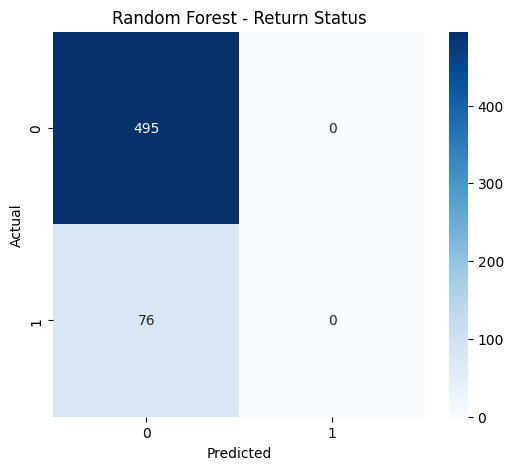

In [153]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    Y_test_class,
    Y_pred_rf_class
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Return Status")

plt.show()